# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


Deskripsi Dataset
Dataset yang digunakan dalam eksperimen ini berfokus pada data ekonomi makro, khususnya Gross Domestic Product (GDP). Data asli mencakup estimasi dan proyeksi GDP global, namun pada eksperimen ini data telah difilter khusus untuk kawasan ASEAN (Indonesia, Malaysia, Singapore, Thailand, Vietnam, Philippines, Brunei, Cambodia, Laos, Myanmar).

Data ini telah melalui proses preprocessing dan feature engineering untuk kebutuhan Time Series Forecasting.

Sumber Dataset: Kaggle - GDP per Country 2020-2025

Rentang Waktu: 2020 - 2025

Cakupan Wilayah: ASEAN (Association of Southeast Asian Nations)

Jenis Masalah: Time Series Regression (Supervised Learning)

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import os
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [3]:
#Type your code here


os.environ['KAGGLE_USERNAME'] = 'pratamaridho'
os.environ['KAGGLE_KEY'] = '83dd63d1b0c651d767e1b1f3b96e80e9'

!kaggle datasets download -d codebynadiia/gdp-per-country-20202025
!unzip gdp-per-country-20202025.zip

df = pd.read_csv('2020-2025.csv')
df.head(10)

Dataset URL: https://www.kaggle.com/datasets/codebynadiia/gdp-per-country-20202025
License(s): MIT
  0% 0.00/5.54k [00:00<?, ?B/s]
100% 5.54k/5.54k [00:00<00:00, 21.2MB/s]
Archive:  gdp-per-country-20202025.zip
  inflating: 2020-2025.csv           


,Country,2020,2021,2022,2023,2024,2025
0,Afghanistan,20136,14278.0,14501.0,17248.0,NaN,NaN
1,Albania,15271,18086.0,19185.0,23388.0,27259.0,28372.0
2,Algeria,164774,185850.0,225709.0,247789.0,264913.0,268885.0
3,Andorra,2885,3325.0,3376.0,3786.0,4038.0,4035.0
4,Angola,66521,84375.0,142442.0,109764.0,115946.0,113343.0
5,Antigua and Barbuda,1412,1602.0,1867.0,2006.0,2225.0,2373.0
6,Argentina,385218,486040.0,632318.0,645511.0,632145.0,683533.0
7,Armenia,12642,13879.0,19514.0,24086.0,25533.0,26258.0
8,Aruba,2486,2929.0,3279.0,3649.0,3952.0,4100.0
9,Australia,1362613,1655843.0,1725461.0,1742461.0,1796805.0,1771681.0


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196 entries, 0 to 195
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Country  196 non-null    object 
 1   2020     196 non-null    int64  
 2   2021     194 non-null    float64
 3   2022     194 non-null    float64
 4   2023     194 non-null    float64
 5   2024     192 non-null    float64
 6   2025     189 non-null    float64
dtypes: float64(5), int64(1), object(1)
memory usage: 10.8+ KB


In [5]:
df.describe()

,2020,2021,2022,2023,2024,2025
count,1.960000e+02,1.940000e+02,1.940000e+02,1.940000e+02,1.920000e+02,1.890000e+02
mean,4.378886e+05,5.043504e+05,5.255064e+05,5.486173e+05,5.756871e+05,5.991414e+05
std,1.942936e+06,2.220864e+06,2.347886e+06,2.453040e+06,2.573189e+06,2.693421e+06
min,5.200000e+01,6.200000e+01,6.100000e+01,6.300000e+01,6.500000e+01,6.500000e+01
25%,9.588000e+03,1.114175e+04,1.265000e+04,1.360450e+04,1.350050e+04,1.421400e+04
50%,3.533450e+04,3.771900e+04,4.156800e+04,4.363100e+04,4.713550e+04,4.782900e+04
75%,2.074810e+05,2.546132e+05,2.746308e+05,2.850355e+05,2.915108e+05,3.032930e+05
max,2.135412e+07,2.368118e+07,2.600690e+07,2.772072e+07,2.918490e+07,3.050722e+07


In [6]:
asean = ["Indonesia", "Malaysia", "Singapore", "Myanmar", "Brunei", "Philipines", "Thailand", "Cambodia", "Laos", "Vietnam"]

In [7]:
df_gdp_asean = df[df['Country'].isin(asean)]
df_gdp_asean.head(10)

,Country,2020,2021,2022,2023,2024,2025
25,Brunei,12006,14006.0,16682.0,15095.0,15463.0,16007.0
30,Cambodia,34898,36797.0,39838.0,43304.0,47328.0,49799.0
78,Indonesia,1059055,1186510.0,1319101.0,1371169.0,1396300.0,1429743.0
94,Laos,18511,18533.0,15121.0,14978.0,15879.0,16322.0
105,Malaysia,337456,373785.0,407605.0,399705.0,419617.0,444984.0
119,Myanmar,65631,58264.0,61723.0,61466.0,61176.0,64944.0
153,Singapore,349166,436591.0,509018.0,505440.0,547387.0,564774.0
173,Thailand,500462,506195.0,495645.0,515906.0,526411.0,546224.0
191,Vietnam,346310,370076.0,411068.0,433008.0,459472.0,490970.0


In [8]:
df_gdp_asean.describe()

,2020,2021,2022,2023,2024,2025
count,9.000000e+00,9.000000e+00,9.000000e+00,9.000000e+00,9.000000e+00,9.000000e+00
mean,3.026106e+05,3.334174e+05,3.639779e+05,3.733412e+05,3.876703e+05,4.026408e+05
std,3.372013e+05,3.768465e+05,4.173569e+05,4.331059e+05,4.426436e+05,4.539688e+05
min,1.200600e+04,1.400600e+04,1.512100e+04,1.497800e+04,1.546300e+04,1.600700e+04
25%,3.489800e+04,3.679700e+04,3.983800e+04,4.330400e+04,4.732800e+04,4.979900e+04
50%,3.374560e+05,3.700760e+05,4.076050e+05,3.997050e+05,4.196170e+05,4.449840e+05
75%,3.491660e+05,4.365910e+05,4.956450e+05,5.054400e+05,5.264110e+05,5.462240e+05
max,1.059055e+06,1.186510e+06,1.319101e+06,1.371169e+06,1.396300e+06,1.429743e+06


In [9]:
# ubah ke long format
df_long = df_gdp_asean.melt(id_vars="Country",
                             value_vars=["2020","2021","2022","2023","2024","2025"],
                             var_name="Year",
                             value_name="GDP")

df_long.head()

,Country,Year,GDP
0,Brunei,2020,12006.0
1,Cambodia,2020,34898.0
2,Indonesia,2020,1059055.0
3,Laos,2020,18511.0
4,Malaysia,2020,337456.0


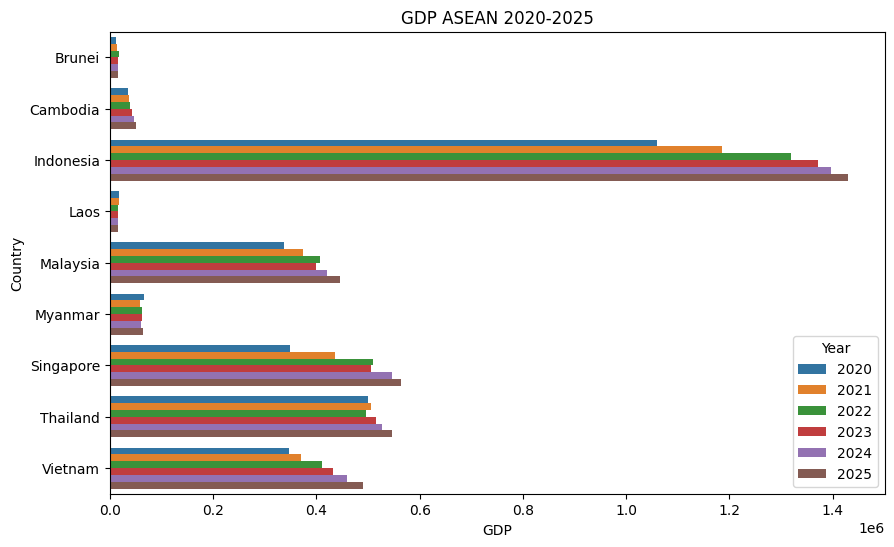

In [10]:
# buat barplot per tahun
plt.figure(figsize=(10,6))
sns.barplot(x="GDP", y="Country", hue="Year", data=df_long)
plt.title("GDP ASEAN 2020-2025")
plt.show()

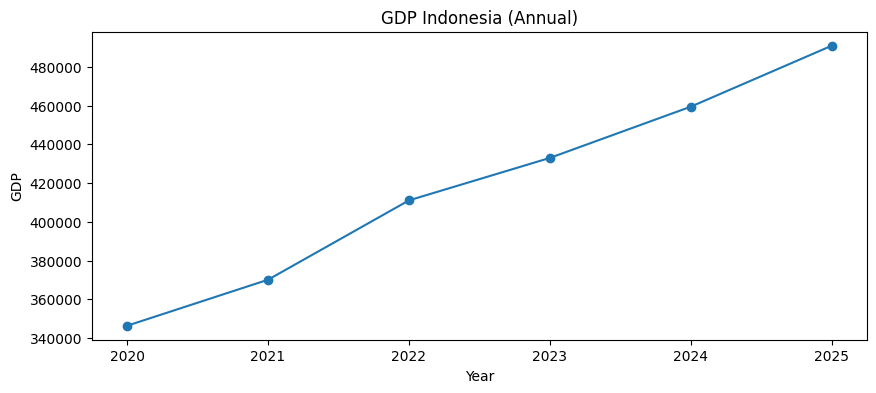

In [11]:
# misal DataFrame lo namanya df_long
series = df_long[df_long['Country']=='Vietnam']  # pake df_long di kedua sisi

# set tahun sebagai index
series = series.set_index('Year')['GDP']

# plot
import matplotlib.pyplot as plt
series.plot(figsize=(10,4), title="GDP Indonesia (Annual)", marker='o')
plt.ylabel('GDP')
plt.show()


# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [18]:
# Cek tipe data saat ini
print(df_long.dtypes)

# Jika GDP masih object/string karena ada koma, hilangkan koma lalu ubah ke float
# df_long['GDP'] = df_long['GDP'].astype(str).str.replace(',', '').astype(float)

# Pastikan Year adalah integer agar bisa diurutkan
df_long['Year'] = df_long['Year'].astype(int)

Country           object
Year               int64
GDP              float64
Country_Code       int64
GDP_Scaled       float64
GDP_Prev_Year    float64
dtype: object


In [19]:

le = LabelEncoder()
df_long['Country_Code'] = le.fit_transform(df_long['Country'])

# Cek hasil
print(df_long[['Country', 'Country_Code']].head())

   Country  Country_Code
0   Brunei             0
9   Brunei             0
18  Brunei             0
27  Brunei             0
36  Brunei             0


In [20]:
scaler = MinMaxScaler()
# Scaling kolom GDP
df_long['GDP_Scaled'] = scaler.fit_transform(df_long[['GDP']])

In [15]:
# Mengurutkan data dulu
df_long = df_long.sort_values(by=['Country', 'Year'])

# Membuat fitur GDP tahun sebelumnya (Lag 1)
df_long['GDP_Prev_Year'] = df_long.groupby('Country')['GDP_Scaled'].shift(1)

# Hapus baris yang jadi NaN (biasanya tahun pertama, 2020, karena tidak ada data 2019)
df_long_clean = df_long.dropna()

print(df_long_clean.head())

   Country  Year      GDP  Country_Code  GDP_Scaled  GDP_Prev_Year
9   Brunei  2021  14006.0             0    0.001411       0.000000
18  Brunei  2022  16682.0             0    0.003298       0.001411
27  Brunei  2023  15095.0             0    0.002179       0.003298
36  Brunei  2024  15463.0             0    0.002438       0.002179
45  Brunei  2025  16007.0             0    0.002822       0.002438


In [16]:


# 1. Simpan DataFrame ke file CSV di penyimpanan sementara Colab
df_long_clean.to_csv('data_gdp_asean_clean.csv', index=False)

# 2. Trigger download agar file masuk ke komputermu
files.download('data_gdp_asean_clean.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>